# 📊 Huấn luyện Hai Mô hình Transformer Chuyên biệt cho Hà Nội (Hanoi-Only)

Notebook này hướng dẫn chi tiết cách xây dựng và huấn luyện độc lập hai mạng nơ-ron Transformer để dự đoán giá bất động sản **riêng tại Hà Nội**:
- **Lọc dữ liệu:** Chỉ lấy các bản ghi có địa bàn hành chính tại Hà Nội.
- **Mô hình Chung cư Hà Nội:** Huấn luyện trên dữ liệu chung cư Hà Nội, loại bỏ các đặc trưng không liên quan (`floors_num`, `frontage_m`, `road_width_m`, `city`).
- **Mô hình Nhà đất Hà Nội:** Huấn luyện trên dữ liệu nhà đất Hà Nội, loại bỏ đặc trưng `city` vì nó là hằng số.

Kết quả huấn luyện sẽ được so sánh đối chiếu ba bên trên cùng tập test Hà Nội (15% độc lập) với:
1. **Hanoi-Only XGBoost** (Baseline huấn luyện riêng cho Hà Nội).
2. **Full Transformer** (Mô hình toàn quốc đã huấn luyện trước đó để đánh giá độ cải thiện của mô hình chuyên biệt).

## 1. Thiết lập Môi trường & Thiết bị Huấn luyện
Chúng ta sẽ import các thư viện khoa học dữ liệu, thiết lập seed ngẫu nhiên bằng 42 và tự động nhận diện phần cứng tăng tốc MPS (Apple Metal) hoặc CUDA.

In [1]:
import os
import sys
import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 240)

warnings.filterwarnings('ignore')

def print_section(title: str) -> None:
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)

# Thiết lập seed
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(42)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Định nghĩa đường dẫn thư mục
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name in ['transformer', 'notebooks']:
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

sys.path.append(str(PROJECT_ROOT))
from transformer_model import HousePriceTransformer

OUTPUT_DIR = PROJECT_ROOT / 'models' / 'transformer' / 'hanoi_only'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print_section('0. THIẾT LẬP MÔI TRƯỜNG THÀNH CÔNG')
print(f'Thiết bị sử dụng: {device}')
print(f'Thư mục lưu mô hình: {OUTPUT_DIR}')


0. THIẾT LẬP MÔI TRƯỜNG THÀNH CÔNG
Thiết bị sử dụng: mps
Thư mục lưu mô hình: /Users/tangoctai/Downloads/House-Price-Prediction-main 2/models/transformer/hanoi_only


## 2. Đọc dữ liệu và Lọc riêng Hà Nội
Chúng ta tiến hành đọc dữ liệu Chung cư và Nhà đất sạch, sau đó lọc duy nhất các bất động sản thuộc Hà Nội.

In [2]:
cc_path = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_chung_cu.csv'
nd_path = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_nha_dat.csv'
df_cc = pd.read_csv(cc_path)
df_nd = pd.read_csv(nd_path)

print_section('1. ĐỌC DỮ LIỆU ĐẦU VÀO')
print(f'Tổng số dòng chung cư cả nước: {len(df_cc):,}')
print(f'Tổng số dòng nhà đất cả nước: {len(df_nd):,}')

# Lọc Hà Nội & Outliers Chung cư
df_cc_clean = df_cc.copy()
if 'balcony_direction' in df_cc_clean.columns:
    df_cc_clean = df_cc_clean.drop(columns=['balcony_direction'])
df_cc_clean = df_cc_clean.dropna(subset=['price_billion', 'area_m2', 'city'])
df_cc_clean['city'] = df_cc_clean['city'].astype(str).str.strip()
df_cc_clean = df_cc_clean[df_cc_clean['city'] == 'Hà Nội']
df_cc_clean = df_cc_clean[(df_cc_clean['price_billion'] >= 1) & (df_cc_clean['price_billion'] <= 200)]
df_cc_clean = df_cc_clean[(df_cc_clean['area_m2'] >= 10) & (df_cc_clean['area_m2'] <= 1000)]

# Lọc Hà Nội & Outliers Nhà đất
df_nd_clean = df_nd.copy()
df_nd_clean = df_nd_clean.dropna(subset=['price_billion', 'area_m2', 'city'])
df_nd_clean['city'] = df_nd_clean['city'].astype(str).str.strip()
df_nd_clean = df_nd_clean[df_nd_clean['city'] == 'Hà Nội']
df_nd_clean = df_nd_clean[(df_nd_clean['price_billion'] >= 1) & (df_nd_clean['price_billion'] <= 200)]
df_nd_clean = df_nd_clean[(df_nd_clean['area_m2'] >= 10) & (df_nd_clean['area_m2'] <= 1000)]

# Đồng nhất kiểu dữ liệu phân loại
for col in ['district', 'direction', 'furniture_std', 'legal_std']:
    if col in df_cc_clean.columns: df_cc_clean[col] = df_cc_clean[col].astype(str).str.strip()
    if col in df_nd_clean.columns: df_nd_clean[col] = df_nd_clean[col].astype(str).str.strip()

print_section('2. SỐ DÒNG DÙNG ĐỂ TRAIN/TEST HÀ NỘI')
print(f'Chung cư Hà Nội: {len(df_cc_clean):,} dòng')
print(f'Nhà đất Hà Nội : {len(df_nd_clean):,} dòng')


1. ĐỌC DỮ LIỆU ĐẦU VÀO
Tổng số dòng chung cư cả nước: 5,452
Tổng số dòng nhà đất cả nước: 6,379

2. SỐ DÒNG DÙNG ĐỂ TRAIN/TEST HÀ NỘI
Chung cư Hà Nội: 1,094 dòng
Nhà đất Hà Nội : 2,718 dòng


## 3. Các hàm bổ trợ xử lý dữ liệu & Đánh giá
Định nghĩa các hàm dùng chung để mapping các trường danh mục (Label Encoding), chuẩn hóa biến số liên tục (Standardization), nạp dữ liệu PyTorch DataLoader và đánh giá mô hình hồi quy.

In [3]:
def make_category_mappings(train_df, cat_features):
    mappings = {}
    for col in cat_features:
        values = sorted(train_df[col].astype(str).unique())
        mappings[col] = {value: idx + 1 for idx, value in enumerate(values)}
    return mappings

def encode_categories(df, cat_features, mappings):
    encoded = []
    for col in cat_features:
        mapping = mappings[col]
        encoded.append(df[col].astype(str).map(mapping).fillna(0).astype('int64').to_numpy())
    return np.stack(encoded, axis=1)

def make_loader(numeric_array, categorical_array, target_array, batch_size, shuffle):
    dataset = TensorDataset(
        torch.tensor(numeric_array, dtype=torch.float32),
        torch.tensor(categorical_array, dtype=torch.long),
        torch.tensor(target_array, dtype=torch.float32)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

def evaluate(model, loader, device, criterion):
    model.eval()
    losses = []
    preds = []
    actuals = []
    with torch.no_grad():
        for num_vals, cat_ids, y in loader:
            num_vals = num_vals.to(device)
            cat_ids = cat_ids.to(device)
            y = y.to(device)
            output = model(num_vals, cat_ids)
            loss = criterion(output, y)
            losses.append(float(loss.item()) * len(y))
            preds.append(output.cpu().numpy())
            actuals.append(y.cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(actuals)
    return sum(losses) / len(y_true), y_pred, y_true

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        'MSE': float(mean_squared_error(y_true, y_pred)),
        'RMSE': rmse,
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'MAPE': float(mean_absolute_percentage_error(y_true, y_pred))
    }

## 4. Hàm Huấn luyện & Đánh giá 3 bên (Hanoi-Only vs XGBoost vs Full Model)
Hàm `train_and_save_model` sẽ chia dữ liệu Hà Nội theo tỷ lệ 70% Train, 15% Val, 15% Test. Đồng thời thực hiện tải model Full (toàn quốc) trước đó để đánh giá so khớp trên cùng tập test Hà Nội 15% này.

In [4]:
def train_and_save_model(df_clean, label, num_features, cat_features, target_col, device, epochs=80, batch_size=64, patience=10):
    print_section(f'HUẤN LUYỆN TRANSFORMER HANOI-ONLY: {label.upper()}')
    
    # 1. Chia Train/Val/Test trên tập Hà Nội theo tỷ lệ 70/15/15
    train_val_df, test_df = train_test_split(df_clean, test_size=0.15, random_state=42)
    train_df, val_df = train_test_split(train_val_df, test_size=0.1765, random_state=42)
    print(f'Chia tập Hà Nội: Train = {len(train_df):,} | Val = {len(val_df):,} | Test = {len(test_df):,}')

    # 2. StandardScaler biến số liên tục
    scaler = StandardScaler()
    train_num = scaler.fit_transform(train_df[num_features])
    val_num = scaler.transform(val_df[num_features])
    test_num = scaler.transform(test_df[num_features])

    # 3. Label encoding đặc trưng phân loại
    mappings = make_category_mappings(train_df, cat_features)
    train_cat = encode_categories(train_df, cat_features, mappings)
    val_cat = encode_categories(val_df, cat_features, mappings)
    test_cat = encode_categories(test_df, cat_features, mappings)

    y_train = train_df[target_col].to_numpy(dtype=np.float32)
    y_val = val_df[target_col].to_numpy(dtype=np.float32)
    y_test = test_df[target_col].to_numpy(dtype=np.float32)

    train_loader = make_loader(train_num, train_cat, y_train, batch_size, shuffle=True)
    val_loader = make_loader(val_num, val_cat, y_val, batch_size, shuffle=False)
    test_loader = make_loader(test_num, test_cat, y_test, batch_size, shuffle=False)

    # 4. Khởi tạo Transformer
    categorical_cardinalities = [len(mappings[col]) + 1 for col in cat_features]
    model = HousePriceTransformer(
        num_numeric=len(num_features),
        categorical_cardinalities=categorical_cardinalities,
        d_model=64,
        nhead=4,
        num_layers=2,
        dim_feedforward=128,
        dropout=0.2
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    best_val_loss = float('inf')
    best_epoch = 0
    wait = 0
    history = []
    suffix = 'cc' if label == 'Chung cư' else 'nd'
    best_state_path = OUTPUT_DIR / f'transformer_model_{suffix}_hn.pt'

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        seen = 0
        for num_vals, cat_ids, y in train_loader:
            num_vals = num_vals.to(device)
            cat_ids = cat_ids.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            output = model(num_vals, cat_ids)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.item()) * len(y)
            seen += len(y)

        train_mse = total_loss / seen
        val_mse, _, _ = evaluate(model, val_loader, device, criterion)
        history.append({'epoch': epoch, 'train_mse': train_mse, 'val_mse': val_mse})

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | Train MSE = {train_mse:.4f} | Validation MSE = {val_mse:.4f}')

        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_epoch = epoch
            wait = 0
            torch.save({
                'state_dict': model.state_dict(),
                'model_params': {
                    'num_numeric': len(num_features),
                    'categorical_cardinalities': categorical_cardinalities,
                    'd_model': 64,
                    'nhead': 4,
                    'num_layers': 2,
                    'dim_feedforward': 128,
                    'dropout': 0.2
                },
                'features': num_features + cat_features,
                'numeric_features': num_features,
                'categorical_features': cat_features,
                'target': target_col
            }, best_state_path)
        else:
            wait += 1
            if wait >= patience:
                print(f'>> Early Stopping kích hoạt ở epoch {epoch}. Epoch tốt nhất: {best_epoch}')
                break

    # Tải trọng số tối ưu
    checkpoint = torch.load(best_state_path, map_location=device)
    model.load_state_dict(checkpoint['state_dict'])

    # Đánh giá Hanoi-Only Transformer
    test_mse, test_pred, test_true = evaluate(model, test_loader, device, criterion)
    test_metrics = regression_metrics(test_true, test_pred)

    # Lưu preprocessing
    preprocessing = {
        'scaler': scaler,
        'category_mappings': mappings,
        'numeric_features': num_features,
        'categorical_features': cat_features,
        'features': num_features + cat_features,
        'target': target_col
    }
    with open(OUTPUT_DIR / f'preprocessing_{suffix}_hn.pkl', 'wb') as f:
        pickle.dump(preprocessing, f)

    # Vẽ biểu đồ Loss Curve
    epochs_list = [item['epoch'] for item in history]
    plt.figure(figsize=(7, 4.5))
    plt.plot(epochs_list, [item['train_mse'] for item in history], label='Train MSE')
    plt.plot(epochs_list, [item['val_mse'] for item in history], label='Validation MSE')
    plt.xlabel('Epoch')
    plt.ylabel('MSE')
    plt.title(f'Loss Curve - Transformer HN ({label})')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'training_loss_{suffix}_hn.png', dpi=150)
    plt.close()

    # Đánh giá Hanoi-Only XGBoost
    xgb = XGBRegressor(n_estimators=100, random_state=42)
    X_train_xgb = np.hstack([train_num, train_cat])
    X_test_xgb = np.hstack([test_num, test_cat])
    xgb.fit(X_train_xgb, y_train)
    xgb_pred = xgb.predict(X_test_xgb)
    xgb_metrics = regression_metrics(y_test, xgb_pred)

    # Đánh giá tham chiếu mô hình Full (toàn quốc) trên tập Test Hà Nội 15%
    checkpoint_full_path = PROJECT_ROOT / 'models' / 'transformer' / 'national' / f'transformer_model_{suffix}.pt'
    preprocessing_full_path = PROJECT_ROOT / 'models' / 'transformer' / 'national' / f'preprocessing_{suffix}.pkl'

    if checkpoint_full_path.exists() and preprocessing_full_path.exists():
        with open(preprocessing_full_path, 'rb') as f:
            prep_full = pickle.load(f)
        checkpoint_full = torch.load(checkpoint_full_path, map_location=device)

        model_full = HousePriceTransformer(**checkpoint_full['model_params']).to(device)
        model_full.load_state_dict(checkpoint_full['state_dict'])
        model_full.eval()

        # Chuẩn hóa test và encode theo preprocessor của model Full
        test_num_full = prep_full['scaler'].transform(test_df[prep_full['numeric_features']])
        test_cat_full = encode_categories(test_df, prep_full['categorical_features'], prep_full['category_mappings'])

        full_loader = make_loader(test_num_full, test_cat_full, y_test, batch_size, shuffle=False)
        _, pred_full, _ = evaluate(model_full, full_loader, device, criterion)
        full_metrics = regression_metrics(y_test, pred_full)
    else:
        print('⚠️ Không tìm thấy mô hình Full toàn quốc, gán metrics mặc định bằng 0.')
        full_metrics = {'MSE': 0.0, 'RMSE': 0.0, 'MAE': 0.0, 'R2': 0.0, 'MAPE': 0.0}

    return test_metrics, xgb_metrics, full_metrics

## 5. Thực thi Huấn luyện mô hình cho Chung cư & Nhà đất Hà Nội
Chúng ta thực thi huấn luyện trên tập dữ liệu đã chuẩn hóa.

In [5]:
num_cc = ['area_m2', 'bedrooms_num']
cat_cc = ['district', 'direction', 'furniture_std', 'legal_std']

num_nd = ['area_m2', 'bedrooms_num', 'floors_num', 'frontage_m', 'road_width_m']
cat_nd = ['district', 'direction', 'furniture_std', 'legal_std']

# Chạy Chung cư Hà Nội
metrics_cc, xgb_cc, full_cc = train_and_save_model(
    df_cc_clean, 'Chung cư', num_cc, cat_cc, 'price_billion', device, epochs=80
)

# Chạy Nhà đất Hà Nội
metrics_nd, xgb_nd, full_nd = train_and_save_model(
    df_nd_clean, 'Nhà đất', num_nd, cat_nd, 'price_billion', device, epochs=80
)


HUẤN LUYỆN TRANSFORMER HANOI-ONLY: CHUNG CƯ
Chia tập Hà Nội: Train = 765 | Val = 164 | Test = 165


Epoch 001 | Train MSE = 78.8910 | Validation MSE = 47.1897


Epoch 010 | Train MSE = 13.2773 | Validation MSE = 9.7691


Epoch 020 | Train MSE = 7.7614 | Validation MSE = 6.5206


Epoch 030 | Train MSE = 5.9416 | Validation MSE = 6.8562
>> Early Stopping kích hoạt ở epoch 30. Epoch tốt nhất: 20


...

Epoch 010 | Train MSE = 74.7750 | Validation MSE = 59.1156


Epoch 020 | Train MSE = 57.3062 | Validation MSE = 60.3797


Epoch 030 | Train MSE = 55.0439 | Validation MSE = 57.2114


Epoch 040 | Train MSE = 47.6339 | Validation MSE = 56.2195


>> Early Stopping kích hoạt ở epoch 46. Epoch tốt nhất: 36


## 6. Trình bày & Đối chiếu kết quả dự đoán trên tập Hà Nội Test
Chúng ta trực quan hóa kết quả dự đoán của 3 mô hình (Hanoi-Only Transformer vs Hanoi-Only XGBoost vs Full Transformer) dạng bảng và lưu vào file CSV.


BẢNG ĐỐI CHIẾU HIỆU NĂNG TRÊN TẬP HÀ NỘI TEST (15% TEST)


,Loại BĐS,Mô hình,R2,MAE,RMSE,MAPE,MSE
0,Chung cư,Transformer HN,0.5945,1.8691,2.9478,21.4%,8.6894
1,Chung cư,XGBoost HN,0.6143,1.8072,2.8748,20.9%,8.2646
2,Chung cư,Transformer Full,0.6719,1.7650,2.6514,19.6%,7.0297
3,Nhà đất,Transformer HN,0.6740,5.1054,9.0013,29.6%,81.0240
4,Nhà đất,XGBoost HN,0.7347,4.7369,8.1192,30.2%,65.9215
5,Nhà đất,Transformer Full,0.7446,4.9984,7.9663,30.8%,63.4619



✅ Đã lưu số liệu vào: /Users/tangoctai/Downloads/House-Price-Prediction-main 2/models/transformer/hanoi_only/comparison_with_xgboost_hn.csv


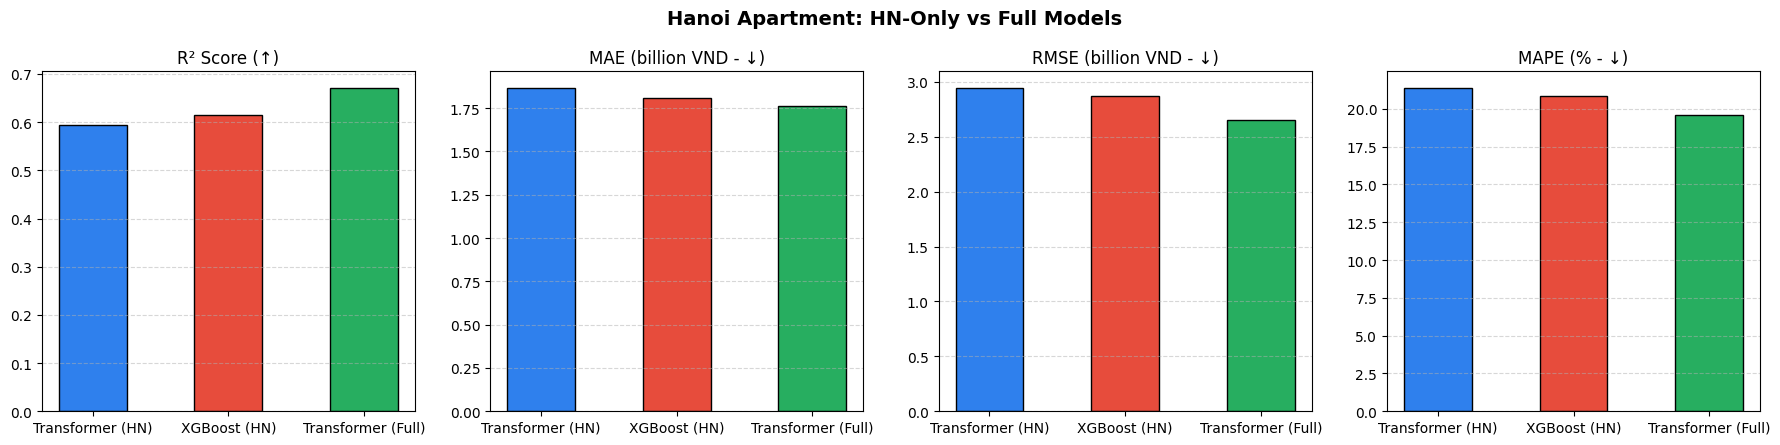

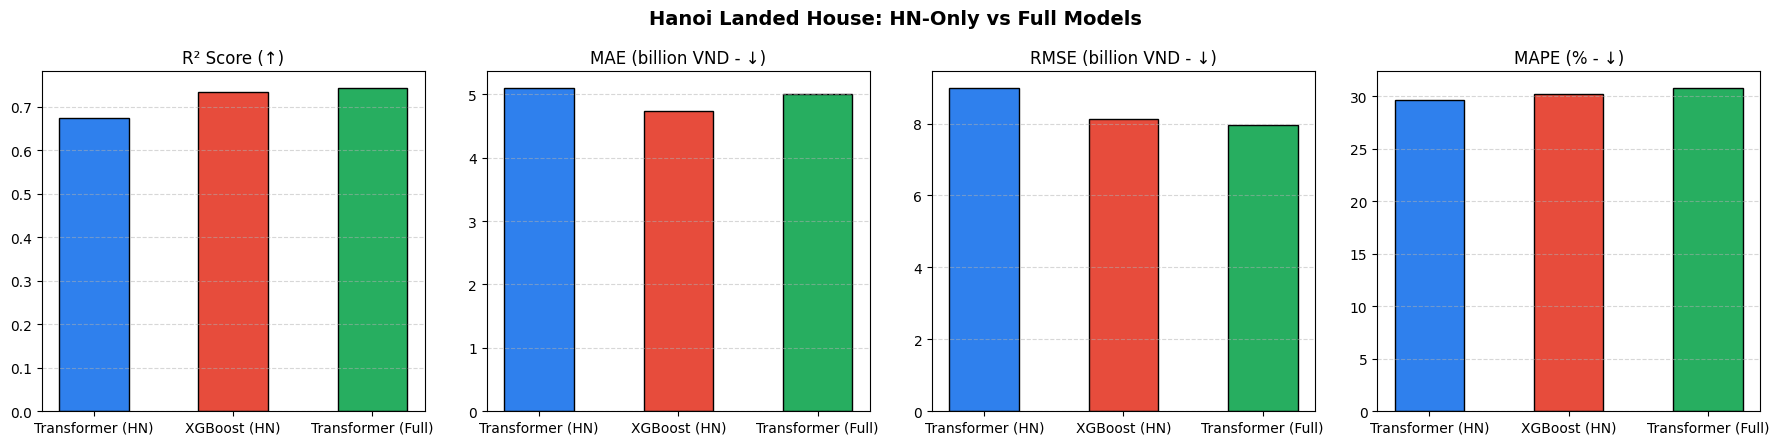


✅ Đã lưu các biểu đồ so sánh vào thư mục outputs!


In [6]:
print_section('BẢNG ĐỐI CHIẾU HIỆU NĂNG TRÊN TẬP HÀ NỘI TEST (15% TEST)')

comparison_df = pd.DataFrame([
    {'Loại BĐS': 'Chung cư', 'Mô hình': 'Transformer HN', 'R2': metrics_cc['R2'], 'MAE': metrics_cc['MAE'], 'RMSE': metrics_cc['RMSE'], 'MAPE': metrics_cc['MAPE'], 'MSE': metrics_cc['MSE']},
    {'Loại BĐS': 'Chung cư', 'Mô hình': 'XGBoost HN', 'R2': xgb_cc['R2'], 'MAE': xgb_cc['MAE'], 'RMSE': xgb_cc['RMSE'], 'MAPE': xgb_cc['MAPE'], 'MSE': xgb_cc['MSE']},
    {'Loại BĐS': 'Chung cư', 'Mô hình': 'Transformer Full', 'R2': full_cc['R2'], 'MAE': full_cc['MAE'], 'RMSE': full_cc['RMSE'], 'MAPE': full_cc['MAPE'], 'MSE': full_cc['MSE']},
    {'Loại BĐS': 'Nhà đất', 'Mô hình': 'Transformer HN', 'R2': metrics_nd['R2'], 'MAE': metrics_nd['MAE'], 'RMSE': metrics_nd['RMSE'], 'MAPE': metrics_nd['MAPE'], 'MSE': metrics_nd['MSE']},
    {'Loại BĐS': 'Nhà đất', 'Mô hình': 'XGBoost HN', 'R2': xgb_nd['R2'], 'MAE': xgb_nd['MAE'], 'RMSE': xgb_nd['RMSE'], 'MAPE': xgb_nd['MAPE'], 'MSE': xgb_nd['MSE']},
    {'Loại BĐS': 'Nhà đất', 'Mô hình': 'Transformer Full', 'R2': full_nd['R2'], 'MAE': full_nd['MAE'], 'RMSE': full_nd['RMSE'], 'MAPE': full_nd['MAPE'], 'MSE': full_nd['MSE']}
])

display(comparison_df.style.format({
    'R2': '{:.4f}', 'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'MAPE': '{:.1%}', 'MSE': '{:.4f}'
}).set_properties(**{
    'text-align': 'left', 'vertical-align': 'middle'
}))

# Xuất số liệu
comparison_df.to_csv(OUTPUT_DIR / 'comparison_with_xgboost_hn.csv', index=False)
print(f'\n✅ Đã lưu số liệu vào: {OUTPUT_DIR / "comparison_with_xgboost_hn.csv"}')

def draw_metrics_chart(hn_trans_m, hn_xgb_m, full_trans_m, title, filename):
    labels = ['Transformer (HN)', 'XGBoost (HN)', 'Transformer (Full)']
    colors = ['#2f80ed', '#e74c3c', '#27ae60']
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(title, fontweight='bold', fontsize=14)
    
    # R2
    axes[0].bar(labels, [hn_trans_m['R2'], hn_xgb_m['R2'], full_trans_m['R2']], color=colors, edgecolor='black', width=0.5)
    axes[0].set_title('R² Score (↑)')
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # MAE
    axes[1].bar(labels, [hn_trans_m['MAE'], hn_xgb_m['MAE'], full_trans_m['MAE']], color=colors, edgecolor='black', width=0.5)
    axes[1].set_title('MAE (billion VND - ↓)')
    axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # RMSE
    axes[2].bar(labels, [hn_trans_m['RMSE'], hn_xgb_m['RMSE'], full_trans_m['RMSE']], color=colors, edgecolor='black', width=0.5)
    axes[2].set_title('RMSE (billion VND - ↓)')
    axes[2].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # MAPE
    axes[3].bar(labels, [hn_trans_m['MAPE'] * 100, hn_xgb_m['MAPE'] * 100, full_trans_m['MAPE'] * 100], color=colors, edgecolor='black', width=0.5)
    axes[3].set_title('MAPE (% - ↓)')
    axes[3].grid(True, axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

draw_metrics_chart(metrics_cc, xgb_cc, full_cc, 'Hanoi Apartment: HN-Only vs Full Models', 'transformer_vs_xgboost_cc_hn.png')
draw_metrics_chart(metrics_nd, xgb_nd, full_nd, 'Hanoi Landed House: HN-Only vs Full Models', 'transformer_vs_xgboost_nd_hn.png')
print(f'\n✅ Đã lưu các biểu đồ so sánh vào thư mục outputs!')